# Neural ODEs Notebook

## Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import diffrax
import optax

## Data Preparation

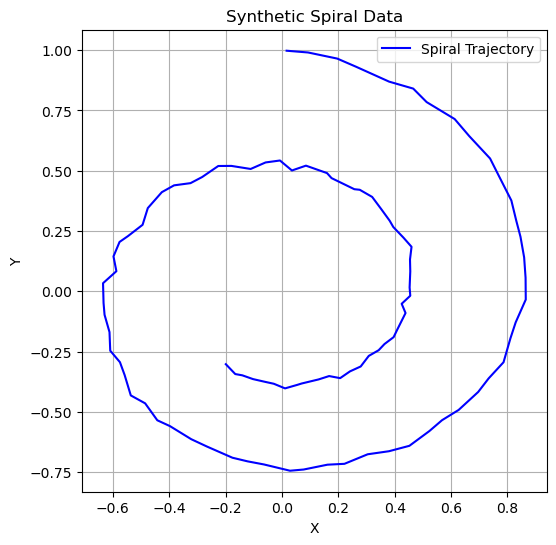

In [2]:
def generate_spiral_data(t, noise_std=0.01):
    x = np.sin(t) * np.exp(-0.1 * t)
    y = np.cos(t) * np.exp(-0.1 * t)
    x = x + np.random.normal(0, noise_std, size=t.shape)
    y = y + np.random.normal(0, noise_std, size=t.shape)
    return np.stack([x, y], axis=-1)  # shape (T, 2)

t = np.linspace(0, 10, 100)
data = generate_spiral_data(t)  # shape (100, 2)

plt.figure(figsize=(6, 6))
plt.plot(data[:, 0], data[:, 1], label="Spiral Trajectory", color="blue")
plt.title("Synthetic Spiral Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.show()

## ODE Function Definition

$$\frac{d\mathbf{y}(t)}{dt} = f_\theta(\mathbf{y}(t), t) = \text{Linear}(2 \to 50) \xrightarrow{\tanh} \text{Linear}(50 \to 2)$$

In [3]:
class Func(eqx.Module):
    """Neural network that parameterizes dy/dt = f(y, t)."""

    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, *, key):
        # depth=1 → Linear(2, 50) → tanh → Linear(50, 2)
        self.mlp = eqx.nn.MLP(
            in_size=data_size,
            out_size=data_size,
            width_size=width_size,
            depth=1,
            activation=jax.nn.tanh,
            key=key,
        )

    def __call__(self, t, y, args):
        return self.mlp(y)

## Neural ODE Model

In [4]:
class NeuralODE(eqx.Module):
    """Wraps Func and solves the ODE with diffrax."""

    func: Func

    def __init__(self, data_size, width_size, *, key):
        self.func = Func(data_size, width_size, key=key)

    def __call__(self, ts, y0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys  # shape (T, data_size)

## Example Usage

In [5]:
key = jr.PRNGKey(42)
model = NeuralODE(data_size=2, width_size=50, key=key)

ts = jnp.array(t)
y0_example = jnp.array(data[0])

predicted = model(ts, y0_example)
print(f"Predicted trajectory shape: {predicted.shape}")  # Expected: (100, 2)

Predicted trajectory shape: (100, 2)


## Training

In [6]:
# Prepare JAX arrays
ts = jnp.array(t)
ys = jnp.array(data)  # shape (100, 2)
y0 = ys[0]           # initial condition

# Hyperparameters
num_steps = 1000
print_every = 100
lr = 0.01

optim = optax.adam(lr)
opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

@eqx.filter_value_and_grad
def loss_fn(model, ts, ys):
    y_pred = model(ts, ys[0])
    return jnp.mean((ys - y_pred) ** 2)

@eqx.filter_jit
def make_step(model, ts, ys, opt_state):
    loss, grads = loss_fn(model, ts, ys)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state

# Training loop
for step in range(num_steps):
    loss, model, opt_state = make_step(model, ts, ys, opt_state)
    if step % print_every == 0:
        print(f"Step {step:4d}, Loss: {loss:.6f}")

Step    0, Loss: 0.982030
Step  100, Loss: 0.169065
Step  200, Loss: 0.143956
Step  300, Loss: 0.010730
Step  400, Loss: 0.000938
Step  500, Loss: 0.000690
Step  600, Loss: 0.000528
Step  700, Loss: 0.000410
Step  800, Loss: 0.000321
Step  900, Loss: 0.000256


## Metrics and Visualization

100
RMSE: 0.017992


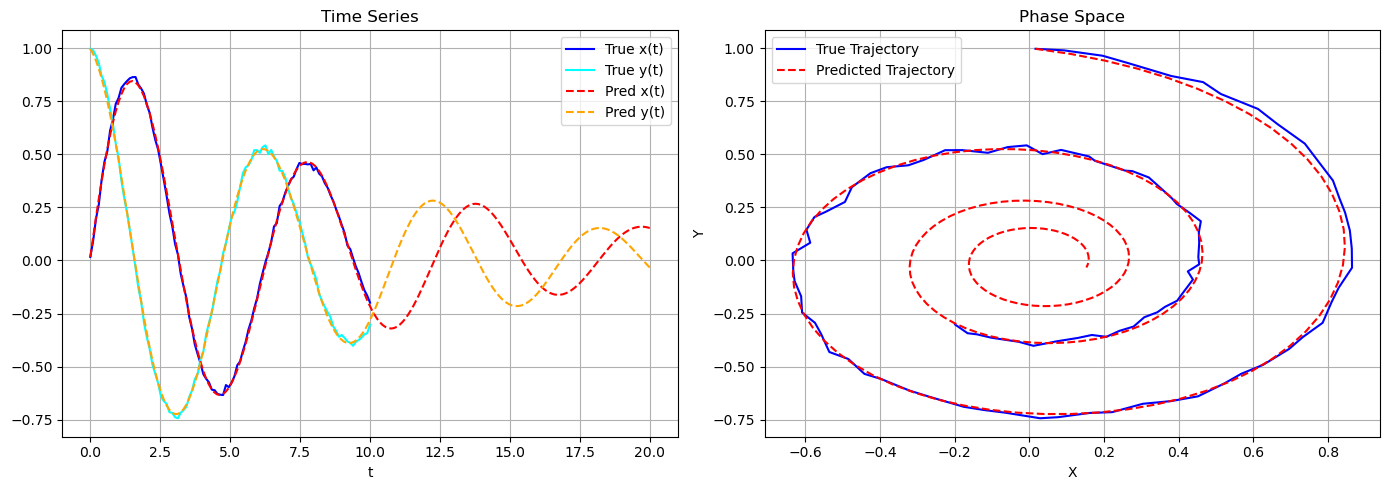

In [7]:
# Test extrapolation
orig_t = ts.shape[0]
print(orig_t)
t = np.linspace(0, 20, 200)
ts2 = jnp.array(t)

predicted_trajectory = model(ts2, ys[0])

rmse = jnp.sqrt(jnp.mean((ys - predicted_trajectory[:orig_t, :]) ** 2))
print(f"RMSE: {rmse:.6f}")

t_np = np.array(ts)
t_np2 = np.array(ts2)
true_np = np.array(ys)
pred_np = np.array(predicted_trajectory)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time-series plot
axes[0].plot(t_np, true_np[:, 0], label="True x(t)", color="blue")
axes[0].plot(t_np, true_np[:, 1], label="True y(t)", color="cyan")
axes[0].plot(t_np2, pred_np[:, 0], label="Pred x(t)", color="red", linestyle="--")
axes[0].plot(t_np2, pred_np[:, 1], label="Pred y(t)", color="orange", linestyle="--")
axes[0].set_title("Time Series")
axes[0].set_xlabel("t")
axes[0].legend()
axes[0].grid()

# Phase-space plot
axes[1].plot(true_np[:, 0], true_np[:, 1], label="True Trajectory", color="blue")
axes[1].plot(pred_np[:, 0], pred_np[:, 1], label="Predicted Trajectory", color="red", linestyle="--")
axes[1].set_title("Phase Space")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()